## Trip purpose isolation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.lines import Line2D


BASE = Path(
    "/Users/mixednutgiftpack/Documents/CASA/OD2017_2023"
)

OUTPUT = BASE / "outputs"
FIGURES = BASE / "figs"
FIGURES.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = [
    "A",
    "B1",
    "B2",
    "C1",
    "C2",
    "DE",
]

CLASS_LABELS = {
    stratum: (
        "D–E"
        if stratum == "DE"
        else stratum
    )
    for stratum in CLASS_ORDER
}

CLASS_COLOURS = {
    "A": "#46085C",
    "B1": "#433E85",
    "B2": "#306A8E",
    "C1": "#21918C",
    "C2": "#32B67A",
    "DE": "#7AD151",
}

PURPOSE_LABELS = {
    1: "Work (industry)",
    2: "Work (commerce)",
    3: "Work (services)",
    4: "Education",
    5: "Shopping",
    6: "Health",
    7: "Leisure",
    8: "Home",
    9: "Job search",
    10: "Personal",
    11: "Meal",
}

MIN_TRIPS = 50

INK = "#3A3F42"
INK_LIGHT = "#6B7075"

In [2]:
persons = pd.read_parquet(
    OUTPUT / "persons_2023.parquet"
)

trips = pd.read_parquet(
    OUTPUT / "trips_2023.parquet"
)

isolation_cells = pd.read_parquet(
    OUTPUT / "isolation_person_cell_hour_2023.parquet",
    columns=[
        "id_pess",
        "hour",
        "hex",
        "isolation",
    ],
)

if "class6" not in persons:
    persons["class6"] = persons["criteriobr"].map(
        {
            1: "A",
            2: "B1",
            3: "B2",
            4: "C1",
            5: "C2",
            6: "DE",
        }
    )


persons["class6"] = persons["class6"].replace(
    {
        "D-E": "DE",
        "D–E": "DE",
        "D−E": "DE",
    }
)


trips = (
    trips
    .drop(
        columns=["class6", "fe_pess"],
        errors="ignore",
    )
    .merge(
        persons[
            [
                "id_pess",
                "class6",
                "fe_pess",
            ]
        ],
        on="id_pess",
        how="inner",
        validate="many_to_one",
    )
)


trip_weight = (
    trips["fe_via"]
    if "fe_via" in trips
    else trips["fe_pess"]
)

trips["trip_weight"] = trip_weight.fillna(
    trips["fe_pess"]
)

In [3]:
destination_trips = trips.copy()



destination_trips["departure_clock"] = (
    destination_trips["h_saida"] * 60
    + destination_trips["min_saida"]
)

destination_trips["arrival_clock"] = (
    destination_trips["h_cheg"] * 60
    + destination_trips["min_cheg"]
)


def survey_day_minutes(clock):
    """Convert clock time to the 04:00–03:59 survey day."""
    return clock + np.where(
        clock < 240,
        1440,
        0,
    )


destination_trips["departure_day"] = survey_day_minutes(
    destination_trips["departure_clock"]
)

destination_trips["arrival_day"] = survey_day_minutes(
    destination_trips["arrival_clock"]
)


# Correct trips crossing midnight
overnight = (
    destination_trips["arrival_day"]
    < destination_trips["departure_day"]
)

destination_trips.loc[
    overnight,
    "arrival_day",
] += 1440


destination_trips = (
    destination_trips
    .sort_values(
        ["id_pess", "departure_day"]
    )
    .reset_index(drop=True)
)

destination_trips["stay_end"] = (
    destination_trips
    .groupby("id_pess")["departure_day"]
    .shift(-1)
    .fillna(1680)
    .clip(upper=1680)
)

destination_trips["purpose"] = (
    destination_trips["motivo_d"]
    .map(PURPOSE_LABELS)
)


destination_trips = destination_trips.loc[
    destination_trips["purpose"].notna()
    & ~destination_trips["purpose"].isin(
        ["Home", "Job search"]
    )
    & destination_trips["hex_d"].notna()
    & destination_trips["arrival_day"].lt(1680)
    & destination_trips["stay_end"].gt(
        destination_trips["arrival_day"]
    )
].copy()

destination_trips["trip_id"] = np.arange(
    len(destination_trips)
)


first_hour = (
    destination_trips["arrival_day"] // 60
).astype(int)

last_hour = (
    (destination_trips["stay_end"] - 1) // 60
).astype(int)

number_of_hours = (
    last_hour - first_hour + 1
)

destination_hours = (
    destination_trips.loc[
        destination_trips.index.repeat(
            number_of_hours
        ),
        [
            "trip_id",
            "id_pess",
            "hex_d",
            "arrival_day",
            "stay_end",
        ],
    ]
    .copy()
)

destination_hours["absolute_hour"] = np.concatenate(
    [
        np.arange(start, end + 1)
        for start, end in zip(
            first_hour,
            last_hour,
        )
    ]
)

destination_hours["hour"] = (
    destination_hours["absolute_hour"] % 24
)


hour_start = (
    destination_hours["absolute_hour"] * 60
)

destination_hours["overlap_minutes"] = (
    np.minimum(
        destination_hours["stay_end"],
        hour_start + 60,
    )
    - np.maximum(
        destination_hours["arrival_day"],
        hour_start,
    )
)

In [4]:
# Attach the corresponding person-cell-hour isolation value
destination_hours = destination_hours.merge(
    isolation_cells.rename(
        columns={"hex": "hex_d"}
    ),
    on=[
        "id_pess",
        "hour",
        "hex_d",
    ],
    how="left",
    validate="many_to_one",
)

valid_destination_hours = (
    destination_hours.loc[
        destination_hours["isolation"].notna()
        & destination_hours["overlap_minutes"].gt(0)
    ]
    .assign(
        isolation_minutes=lambda data: (
            data["isolation"]
            * data["overlap_minutes"]
        )
    )
)


# Calculate valid-minute-weighted isolation 
trip_isolation = (
    valid_destination_hours
    .groupby("trip_id")
    .agg(
        isolation_minutes=(
            "isolation_minutes",
            "sum",
        ),
        valid_minutes=(
            "overlap_minutes",
            "sum",
        ),
    )
    .assign(
        iso_stay=lambda data: (
            data["isolation_minutes"]
            / data["valid_minutes"]
        )
    )
)


destination_trips = (
    destination_trips
    .merge(
        trip_isolation[
            [
                "iso_stay",
                "valid_minutes",
            ]
        ],
        left_on="trip_id",
        right_index=True,
        how="inner",
        validate="one_to_one",
    )
    .assign(
        weighted_isolation=lambda data: (
            data["iso_stay"]
            * data["trip_weight"]
        )
    )
)


purpose_isolation = (
    destination_trips
    .groupby(
        ["class6", "purpose"],
        observed=True,
    )
    .agg(
        n=("trip_id", "size"),
        weighted_isolation=(
            "weighted_isolation",
            "sum",
        ),
        survey_weight=(
            "trip_weight",
            "sum",
        ),
    )
    .assign(
        iso=lambda data: (
            data["weighted_isolation"]
            / data["survey_weight"]
        )
    )
    .reset_index()
    .loc[
        lambda data: data["n"].ge(MIN_TRIPS),
        [
            "class6",
            "purpose",
            "n",
            "iso",
        ],
    ]
    .reset_index(drop=True)
)


purpose_isolation.to_csv(
    OUTPUT / "purpose_isolation_mean_2023.csv",
    index=False,
)

display(
    purpose_isolation
    .sort_values(
        ["purpose", "class6"]
    )
    .style.format(
        {
            "n": "{:,.0f}",
            "iso": "{:.2f}",
        }
    )
)

,class6,purpose,n,iso
0,A,Education,642,3.23
9,B1,Education,623,2.14
18,B2,Education,"1,451",1.20
27,C1,Education,"1,206",1.00
36,C2,Education,860,1.21
45,DE,Education,181,1.57
1,A,Health,268,2.75
10,B1,Health,341,1.84
19,B2,Health,692,1.17
28,C1,Health,648,1.02


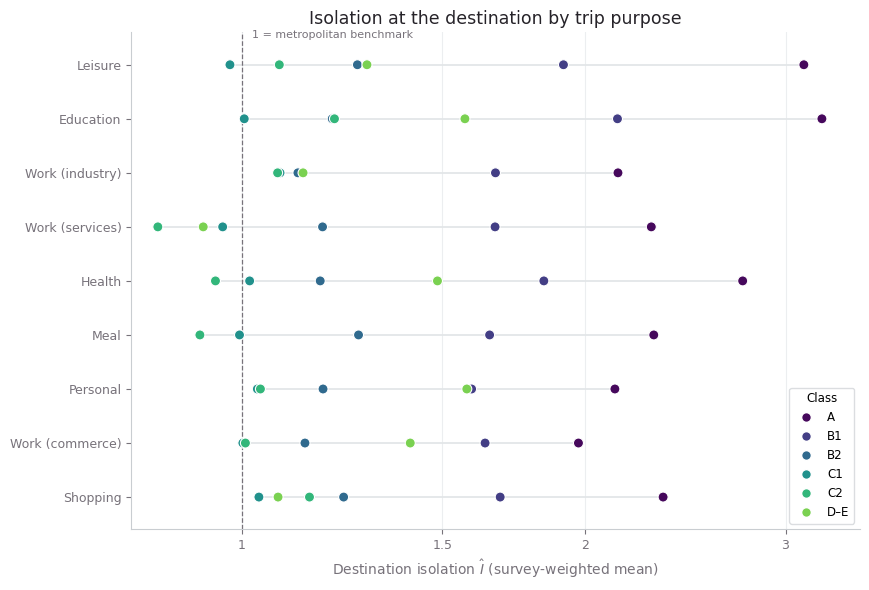

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/c6_fig10_purpose_iso.png


In [16]:
preferred_order = [
    "Shopping",
    "Work (commerce)",
    "Personal",
    "Meal",
    "Health",
    "Work (services)",
    "Work (industry)",
    "Education",
    "Leisure",
]

purpose_order = [
    purpose
    for purpose in preferred_order
    if purpose in purpose_isolation["purpose"].unique()
]


purpose_matrix = (
    purpose_isolation
    .pivot(
        index="purpose",
        columns="class6",
        values="iso",
    )
    .reindex(
        index=purpose_order,
        columns=CLASS_ORDER,
    )
)


fig, ax = plt.subplots(
    figsize=(8.8, 6),
    facecolor="white",
)


for y, purpose in enumerate(purpose_order):
    values = purpose_matrix.loc[
        purpose
    ].dropna()

    if values.empty:
        continue

    ax.hlines(
        y,
        values.min(),
        values.max(),
        color="#E3E6E8",
        linewidth=1.3,
        zorder=1,
    )
    ax.scatter(
        values,
        np.full(len(values), y),
        s=52,
        c=[
            CLASS_COLOURS[stratum]
            for stratum in values.index
        ],
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )


# Metropolitan benchmark
ax.axvline(
    1,
    color=INK_LIGHT,
    linewidth=0.9,
    linestyle="--",
)

ax.text(
    1.02,
    len(purpose_order) - 0.35,
    "1 = metropolitan benchmark",
    color=INK_LIGHT,
    fontsize=8,
    va="top",
)


ax.set(
    xscale="log",
    xlim=(
        0.8,
        max(
            3.2,
            purpose_isolation["iso"].max() * 1.08,
        ),
    ),
    ylim=(
        -0.6,
        len(purpose_order) - 0.4,
    ),
    xticks=[1, 1.5, 2, 3],
    xticklabels=["1", "1.5", "2", "3"],
    yticks=range(len(purpose_order)),
    yticklabels=purpose_order,
    xlabel=(
        "Destination isolation "
        r"$\hat{I}$ (survey-weighted mean)"
    ),
    title="Isolation at the destination by trip purpose",
)

ax.xaxis.label.set_color(INK_LIGHT)

ax.title.set(
    color=INK,
    fontsize=12.5,
)

ax.minorticks_off()


# Class legend
legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        markersize=7,
        linestyle="none",
        markerfacecolor=CLASS_COLOURS[stratum],
        markeredgecolor="white",
        label=CLASS_LABELS[stratum],
    )
    for stratum in CLASS_ORDER
]

ax.legend(
    handles=legend_handles,
    title="Class",
    loc="lower right",
    fontsize=8.5,
    title_fontsize=8.5,
    framealpha=0.95,
    edgecolor="#D9DCDF",
)


# Shared figure style
ax.spines[["top", "right"]].set_visible(False)

ax.spines[["left", "bottom"]].set_color(
    "#C9CDD1"
)

ax.tick_params(
    colors=INK_LIGHT,
    labelsize=9,
)

ax.grid(
    axis="x",
    color="#ECEEF0",
    linewidth=0.8,
)

ax.set_axisbelow(True)

fig.tight_layout()


figure_path = (
    FIGURES
    / "c6_fig10_purpose_iso.png"
)

fig.savefig(
    figure_path,
    dpi=170,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved: {figure_path}")

## 4.13

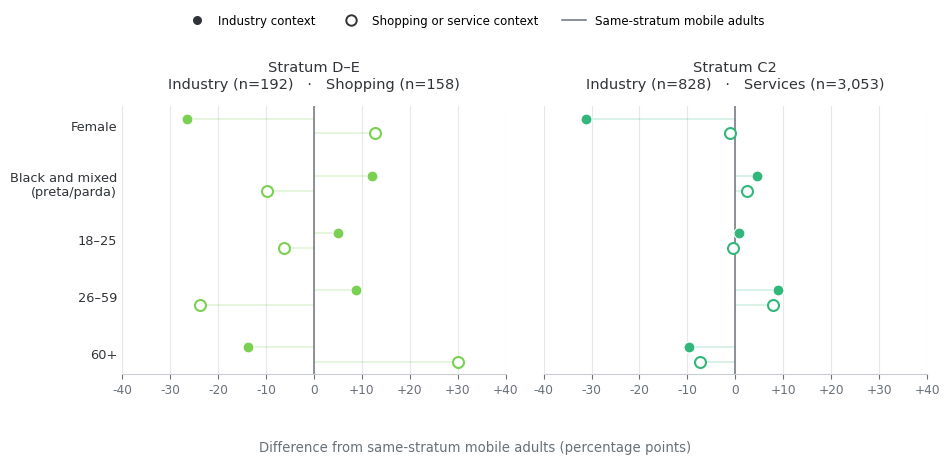

Saved CSV: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/outputs/fig4_15_participant_composition_2023.csv
Saved figure: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/c6_fig15_participant_composition_2023.png


In [20]:
from matplotlib.ticker import FuncFormatter
FIGURE_PATH = (
    FIGURES
    / "c6_fig15_participant_composition_2023.png"
)

OUTPUT_PATH = (
    OUTPUT
    / "fig4_15_participant_composition_2023.csv"
)


# Selected activity contexts
PLOT_CASES = {
    "DE": {
        "title": "Stratum D–E",
        "contexts": {
            "Industry": 1,
            "Shopping": 5,
        },
    },
    "C2": {
        "title": "Stratum C2",
        "contexts": {
            "Industry": 1,
            "Services": 3,
        },
    },
}

CATEGORIES = {
    "Female": (
        "gender",
        "F",
    ),
    "Black and mixed\n(preta/parda)": (
        "race_group",
        "negra",
    ),
    "18–25": (
        "age_group",
        "18–25",
    ),
    "26–59": (
        "age_group",
        "26–59",
    ),
    "60+": (
        "age_group",
        "60+",
    ),
}


persons = persons.copy()

persons["class6"] = (
    persons["class6"]
    .replace(
        {
            "D-E": "DE",
            "D–E": "DE",
            "D−E": "DE",
        }
    )
)

persons["age_group"] = pd.cut(
    persons["idade"],
    bins=[
        17,
        25,
        59,
        np.inf,
    ],
    labels=[
        "18–25",
        "26–59",
        "60+",
    ],
)


def weighted_share(data, column, value):
    """Calculate a survey-weighted category share."""
    valid = (
        data[column].notna()
        & data["fe_pess"].notna()
        & data["fe_pess"].gt(0)
    )

    if not valid.any():
        return np.nan

    return np.average(
        data.loc[valid, column].eq(value),
        weights=data.loc[valid, "fe_pess"],
    )

# Calculate participant composition

composition_rows = []

for stratum, case in PLOT_CASES.items():
    reference = persons.loc[
        persons["class6"].eq(stratum)
        & persons["mobile"]
    ]

    for context, purpose_code in (
        case["contexts"].items()
    ):
        participant_ids = (
            trips.loc[
                trips["motivo_d"].eq(purpose_code),
                "id_pess",
            ]
            .dropna()
            .unique()
        )

        participants = persons.loc[
            persons["class6"].eq(stratum)
            & persons["id_pess"].isin(participant_ids)
        ]

        for category, (
            column,
            value,
        ) in CATEGORIES.items():
            context_share = weighted_share(
                participants,
                column,
                value,
            )

            reference_share = weighted_share(
                reference,
                column,
                value,
            )

            composition_rows.append(
                {
                    "class6": stratum,
                    "activity_context": context,
                    "category": category,
                    "participant_n": len(participants),
                    "reference_n": len(reference),
                    "context_share": context_share,
                    "reference_share": reference_share,
                    "difference_pp": (
                        context_share
                        - reference_share
                    ) * 100,
                }
            )


composition_table = pd.DataFrame(
    composition_rows
)

composition_table.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)


display_categories = list(CATEGORIES)

y_positions = {
    category: (
        len(display_categories)
        - 1
        - index
    )
    for index, category
    in enumerate(display_categories)
}

maximum_difference = (
    composition_table["difference_pp"]
    .abs()
    .max()
)

x_limit = max(
    10,
    int(
        np.ceil(
            maximum_difference / 10
        ) * 10
    ),
)

TEXT = "#303438"
MUTED = "#687078"
GRID = "#E5E8EA"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.6, 4.7),
    sharex=True,
    sharey=True,
    facecolor="white",
)


for ax, (
    stratum,
    case,
) in zip(
    axes,
    PLOT_CASES.items(),
):
    colour = CLASS_COLOURS[stratum]

    contexts = list(
        case["contexts"]
    )

    for context_index, context in enumerate(
        contexts
    ):
        context_data = (
            composition_table.loc[
                composition_table["class6"].eq(stratum)
                & composition_table[
                    "activity_context"
                ].eq(context)
            ]
            .set_index("category")
            .reindex(display_categories)
        )

        x = context_data[
            "difference_pp"
        ].to_numpy(float)

        y = np.array(
            [
                y_positions[category]
                for category
                in display_categories
            ]
        ) + (
            0.13
            if context_index == 0
            else -0.13
        )

        valid = np.isfinite(x)

        ax.hlines(
            y[valid],
            0,
            x[valid],
            color=colour,
            linewidth=1.1,
            alpha=0.24,
            zorder=1,
        )

        ax.scatter(
            x[valid],
            y[valid],
            s=62,
            facecolor=(
                colour
                if context_index == 0
                else "white"
            ),
            edgecolor=(
                "white"
                if context_index == 0
                else colour
            ),
            linewidth=(
                0.8
                if context_index == 0
                else 1.5
            ),
            zorder=3,
        )

    sample_sizes = (
        composition_table.loc[
            composition_table["class6"].eq(
                stratum
            )
        ]
        .drop_duplicates(
            "activity_context"
        )
        .set_index(
            "activity_context"
        )["participant_n"]
    )

    ax.set_title(
        (
            f"{case['title']}\n"
            f"{contexts[0]} "
            f"(n={sample_sizes[contexts[0]]:,})"
            "   ·   "
            f"{contexts[1]} "
            f"(n={sample_sizes[contexts[1]]:,})"
        ),
        fontsize=10.5,
        color=TEXT,
        pad=13,
    )

    ax.axvline(
        0,
        color="#737A80",
        linewidth=1.15,
    )

    ax.set(
        xlim=(-x_limit, x_limit),
        yticks=[
            y_positions[category]
            for category
            in display_categories
        ],
        yticklabels=display_categories,
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, _: (
                f"{value:+.0f}"
                if value
                else "0"
            )
        )
    )

    ax.grid(
        axis="x",
        color=GRID,
        linewidth=0.8,
    )

    ax.set_axisbelow(True)
    ax.spines[
        ["top", "right", "left"]
    ].set_visible(False)

    ax.spines["bottom"].set_color(
        "#C9CDD1"
    )

    ax.tick_params(
        axis="y",
        length=0,
        labelsize=9.3,
        colors=TEXT,
    )

    ax.tick_params(
        axis="x",
        labelsize=8.8,
        colors=MUTED,
    )


# Legend and labels

legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markersize=7.5,
        markerfacecolor=TEXT,
        markeredgecolor="white",
        label="Industry context",
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markersize=7.5,
        markerfacecolor="white",
        markeredgecolor=TEXT,
        markeredgewidth=1.4,
        label="Shopping or service context",
    ),
    Line2D(
        [],
        [],
        color="#737A80",
        linewidth=1.15,
        label="Same-stratum mobile adults",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False,
    fontsize=8.5,
)


fig.supxlabel(
    (
        "Difference from same-stratum mobile adults "
        "(percentage points)"
    ),
    fontsize=9.5,
    color=MUTED,
    y=0.02,
)

fig.tight_layout(
    rect=[0, 0.05, 1, 0.89]
)


fig.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved CSV: {OUTPUT_PATH}")
print(f"Saved figure: {FIGURE_PATH}")

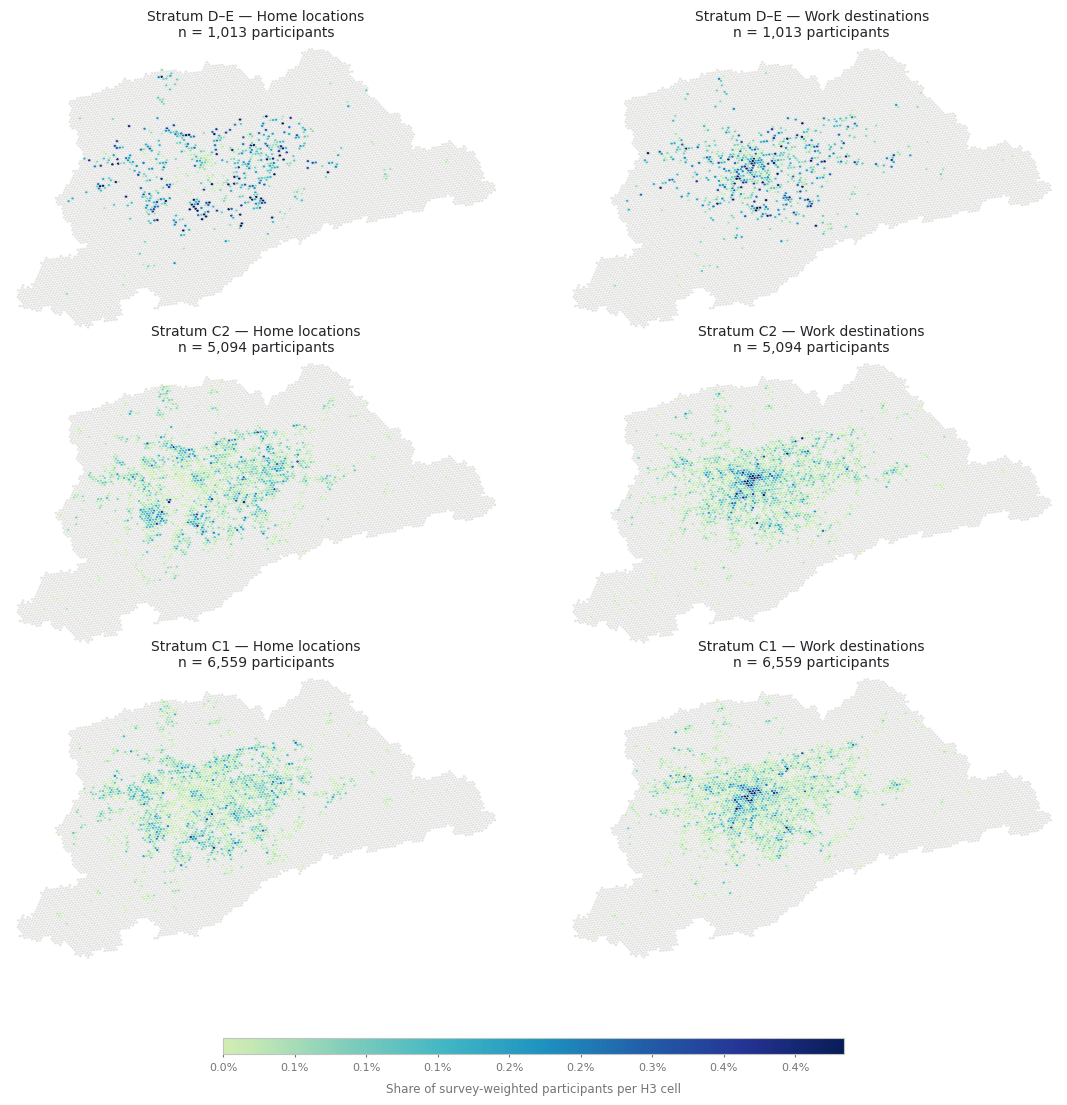

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/figure_4_15_home_work_de_c2.png
Stratum D–E — Home locations n=1,013
Stratum D–E — Work destinations n=1,013
Stratum C2 — Home locations n=5,094
Stratum C2 — Work destinations n=5,094
Stratum C1 — Home locations n=6,559
Stratum C1 — Work destinations n=6,559


In [17]:
import h3
import geopandas as gpd
import matplotlib.colors as mcolors

from matplotlib.cm import ScalarMappable
from matplotlib.collections import PolyCollection
from matplotlib.ticker import PercentFormatter


plt.close("all")

FIGURE_PATH = (
    FIGURES
    / "figure_4_15_home_work_de_c2.png"
)

SHAPE_DIR = BASE / "2023_OD" / "Shape"

MAP_CLASS_ORDER = ["DE", "C2", "C1"]

MAP_CLASS_LABELS = {
    "DE": "Stratum D–E",
    "C2": "Stratum C2",
    "C1": "Stratum C1",
}

WORK_CODES = [1, 2, 3]
EMPTY_HEX = "#E2E3E1"


# Shared sequential colour scale
base_cmap = plt.colormaps["YlGnBu"]

MAP_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "YlGnBu_stronger",
    base_cmap(
        np.linspace(0.22, 1, 256)
    ),
)

map_persons = persons[
    [
        "id_pess",
        "class6",
        "fe_pess",
        "hex_home",
    ]
].copy()

map_trips = trips[
    [
        "id_pess",
        "motivo_d",
        "hex_d",
    ]
].copy()

municipalities = (
    gpd.read_file(
        SHAPE_DIR / "Municipios_2023.shp"
    )
    .to_crs(4326)
)


def standardise_class(series):
    """Standardise possible D–E labels."""
    return (
        series.astype(str)
        .str.replace(
            r"^D[\-\–\—\‑]E$",
            "DE",
            regex=True,
        )
    )


map_persons["class6"] = standardise_class(
    map_persons["class6"]
)

map_persons["hex_home"] = (
    map_persons["hex_home"].astype("string")
)

map_persons["fe_pess"] = pd.to_numeric(
    map_persons["fe_pess"],
    errors="coerce",
)

map_persons = (
    map_persons
    .dropna(
        subset=[
            "id_pess",
            "class6",
            "fe_pess",
            "hex_home",
        ]
    )
    .drop_duplicates("id_pess")
    .loc[
        lambda data: (
            data["class6"].isin(MAP_CLASS_ORDER)
            & data["fe_pess"].gt(0)
        )
    ]
    .copy()
)

map_trips["motivo_d"] = pd.to_numeric(
    map_trips["motivo_d"],
    errors="coerce",
)

map_trips["hex_d"] = (
    map_trips["hex_d"].astype("string")
)

work_trips = (
    map_trips.loc[
        map_trips["motivo_d"].isin(WORK_CODES)
    ]
    .dropna(
        subset=["id_pess", "hex_d"]
    )
    .drop_duplicates(
        ["id_pess", "hex_d"]
    )
)

# H3 metropolitan footprint

if hasattr(h3, "cell_to_boundary"):
    cell_boundary = h3.cell_to_boundary
else:
    cell_boundary = h3.h3_to_geo_boundary


def hex_polygon(cell):
    return [
        (longitude, latitude)
        for latitude, longitude
        in cell_boundary(str(cell))
    ]


sample_cells = pd.concat(
    [
        map_persons["hex_home"],
        work_trips["hex_d"],
    ],
    ignore_index=True,
).dropna()

if sample_cells.empty:
    raise ValueError(
        "No valid H3 cells were found."
    )

sample_hex = str(sample_cells.iloc[0])

if hasattr(h3, "get_resolution"):
    h3_resolution = h3.get_resolution(
        sample_hex
    )
else:
    h3_resolution = h3.h3_get_resolution(
        sample_hex
    )


if hasattr(municipalities.geometry, "union_all"):
    metropolitan_geometry = (
        municipalities.geometry.union_all()
    )
else:
    metropolitan_geometry = (
        municipalities.geometry.unary_union
    )


geometry_parts = (
    [metropolitan_geometry]
    if metropolitan_geometry.geom_type == "Polygon"
    else [
        geometry
        for geometry in metropolitan_geometry.geoms
        if geometry.geom_type == "Polygon"
    ]
)

metropolitan_cells = set()

for polygon in geometry_parts:
    if hasattr(h3, "geo_to_cells"):
        cells = h3.geo_to_cells(
            polygon.__geo_interface__,
            h3_resolution,
        )
    else:
        cells = h3.polyfill(
            polygon.__geo_interface__,
            h3_resolution,
            geo_json_conformant=True,
        )

    metropolitan_cells.update(
        map(str, cells)
    )


metropolitan_cells = sorted(
    metropolitan_cells
)

metropolitan_cell_set = set(
    metropolitan_cells
)

metropolitan_polygons = [
    hex_polygon(cell)
    for cell in metropolitan_cells
]

# Calculate home and work distribution
def weighted_distribution(
    data,
    hex_column,
    weight_column,
):
    """Calculate each H3 cell's share of total survey weight."""
    return (
        data
        .groupby(
            hex_column,
            as_index=False,
        )
        .agg(
            weighted_participants=(
                weight_column,
                "sum",
            )
        )
        .rename(
            columns={hex_column: "hex"}
        )
        .assign(
            share=lambda table: (
                table["weighted_participants"]
                / table[
                    "weighted_participants"
                ].sum()
            )
        )
    )


def make_class_distributions(class_code):
    """Return comparable home and work distributions."""
    class_persons = map_persons.loc[
        map_persons["class6"].eq(class_code)
    ]

    class_work = (
        work_trips
        .merge(
            class_persons[
                [
                    "id_pess",
                    "fe_pess",
                    "hex_home",
                ]
            ],
            on="id_pess",
            how="inner",
            validate="many_to_one",
        )
        .loc[
            lambda data: (
                data["hex_d"]
                .astype(str)
                .isin(metropolitan_cell_set)
            )
        ]
        .drop_duplicates(
            ["id_pess", "hex_d"]
        )
    )

    if class_work.empty:
        raise ValueError(
            f"No work destinations for {class_code}."
        )

    eligible_ids = class_work[
        "id_pess"
    ].unique()

    eligible_persons = (
        class_persons.loc[
            class_persons["id_pess"].isin(
                eligible_ids
            )
            & class_persons["hex_home"]
            .astype(str)
            .isin(metropolitan_cell_set)
        ]
        .drop_duplicates("id_pess")
    )

    common_ids = np.intersect1d(
        eligible_persons["id_pess"],
        class_work["id_pess"],
    )

    eligible_persons = eligible_persons.loc[
        eligible_persons["id_pess"].isin(
            common_ids
        )
    ]

    class_work = class_work.loc[
        class_work["id_pess"].isin(
            common_ids
        )
    ].copy()

    # Divide each person's weight across their work cells
    work_cell_count = (
        class_work
        .groupby("id_pess")["hex_d"]
        .transform("nunique")
    )

    class_work["allocated_weight"] = (
        class_work["fe_pess"]
        / work_cell_count
    )

    home_distribution = weighted_distribution(
        eligible_persons,
        "hex_home",
        "fe_pess",
    )

    work_distribution = weighted_distribution(
        class_work,
        "hex_d",
        "allocated_weight",
    )

    return (
        home_distribution,
        work_distribution,
        len(common_ids),
    )


panels = []

for class_code in MAP_CLASS_ORDER:
    home, work, n_people = (
        make_class_distributions(
            class_code
        )
    )

    panels.extend(
        [
            {
                "title": (
                    f"{MAP_CLASS_LABELS[class_code]} "
                    "— Home locations"
                ),
                "data": home,
                "n": n_people,
            },
            {
                "title": (
                    f"{MAP_CLASS_LABELS[class_code]} "
                    "— Work destinations"
                ),
                "data": work,
                "n": n_people,
            },
        ]
    )


# Shared colour scale
all_shares = pd.concat(
    [
        panel["data"]["share"]
        for panel in panels
    ]
)

SHARE_VMAX = all_shares.quantile(0.99)

share_norm = mcolors.Normalize(
    vmin=0,
    vmax=SHARE_VMAX,
)

for panel in panels:
    panel["polygons"] = [
        hex_polygon(cell)
        for cell in panel["data"]["hex"]
    ]

    panel["values"] = (
        panel["data"]["share"]
        .clip(upper=SHARE_VMAX)
        .to_numpy()
    )


min_x, min_y, max_x, max_y = (
    municipalities.total_bounds
)

x_margin = (max_x - min_x) * 0.012
y_margin = (max_y - min_y) * 0.012

XLIM = (
    min_x - x_margin,
    max_x + x_margin,
)

YLIM = (
    min_y - y_margin,
    max_y + y_margin,
)


def draw_distribution_map(axis, panel):
    """Draw one home or work distribution panel."""
    axis.add_collection(
        PolyCollection(
            metropolitan_polygons,
            facecolor=EMPTY_HEX,
            edgecolor="white",
            linewidth=0.25,
            zorder=1,
        )
    )

    axis.add_collection(
        PolyCollection(
            panel["polygons"],
            array=panel["values"],
            cmap=MAP_CMAP,
            norm=share_norm,
            edgecolor="white",
            linewidth=0.25,
            zorder=2,
        )
    )

    axis.set(
        xlim=XLIM,
        ylim=YLIM,
        aspect="equal",
        title=(
            f"{panel['title']}\n"
            f"n = {panel['n']:,} participants"
        ),
    )

    axis.title.set(
        fontsize=10,
        fontweight="normal",
        color=INK,
    )

    axis.set_axis_off()


# Draw figure
figure, axes = plt.subplots(
    3,
    2,
    figsize=(11.5, 11.6),
    facecolor="white",
)

for axis, panel in zip(
    axes.flat,
    panels,
):
    draw_distribution_map(
        axis,
        panel,
    )




figure.subplots_adjust(
    top=0.93,
    bottom=0.14,
    left=0.025,
    right=0.975,
    wspace=0.035,
    hspace=0.10,
)


# Shared horizontal colour bar
colourbar_axis = figure.add_axes(
    [0.23, 0.060, 0.54, 0.014]
)

colourbar = figure.colorbar(
    ScalarMappable(
        cmap=MAP_CMAP,
        norm=share_norm,
    ),
    cax=colourbar_axis,
    orientation="horizontal",
)

colourbar.ax.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=1,
        decimals=1,
    )
)

colourbar.ax.tick_params(
    labelsize=8,
    colors=INK_LIGHT,
    length=2.5,
)

colourbar.outline.set_edgecolor(
    "#BFC3C1"
)

colourbar.set_label(
    "Share of survey-weighted participants per H3 cell",
    fontsize=8.5,
    color=INK_LIGHT,
    labelpad=7,
)


figure.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved: {FIGURE_PATH}")

for panel in panels:
    print(
        panel["title"],
        f"n={panel['n']:,}",
    )

## I

Matched work stays: 27,107


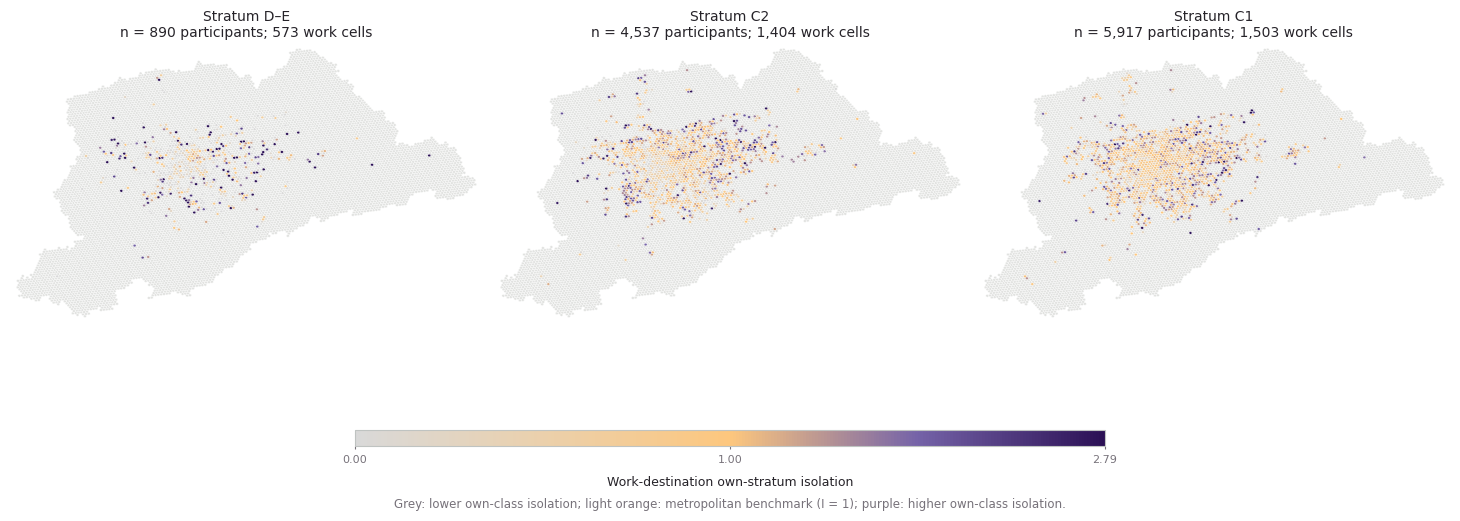

Saved map data: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/outputs/work_destination_isolation_hex_2023.parquet
Saved figure: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/figure_4_16_work_destination_isolation_2023.png


,work_cells,mean_I,median_I,participants
class6,,,,
DE,573,0.908,0.401,890
C2,1404,0.864,0.747,4537
C1,1503,0.914,0.845,5917


In [18]:
FIGURE_PATH = (
    FIGURES
    / "figure_4_16_work_destination_isolation_2023.png"
)

DATA_PATH = (
    OUTPUT
    / "work_destination_isolation_hex_2023.parquet"
)

WORK_CLASS_ORDER = ["DE", "C2", "C1"]

WORK_CLASS_LABELS = {
    "DE": "Stratum D–E",
    "C2": "Stratum C2",
    "C1": "Stratum C1",
}

WORK_ISO_CMAP = (
    mcolors.LinearSegmentedColormap.from_list(
        "work_isolation",
        [
            (0.00, "#D9D9D9"),
            (0.50, "#FDC77E"),
            (0.75, "#7563A8"),
            (1.00, "#2B1055"),
        ],
    )
)

work_trip_arrivals = (
    trips.loc[
        trips["motivo_d"].isin(WORK_CODES),
        [
            "id_pess",
            "arrival_minute",
            "hex_d",
        ],
    ]
    .dropna(
        subset=[
            "id_pess",
            "arrival_minute",
            "hex_d",
        ]
    )
    .drop_duplicates(
        ["id_pess", "arrival_minute", "hex_d"]
    )
    .copy()
)

stays = pd.read_parquet(
    OUTPUT / "stays_2023.parquet",
    columns=[
        "id_pess",
        "hex",
        "start",
        "end",
        "stay_type",
    ],
)

person_hour = pd.read_parquet(
    OUTPUT / "isolation_person_cell_hour_2023.parquet",
    columns=[
        "id_pess",
        "hour",
        "hex",
        "fe_pess",
        "class6",
        "isolation",
        "low_support",
    ],
)


for column in ["arrival_minute"]:
    work_trip_arrivals[column] = pd.to_numeric(
        work_trip_arrivals[column],
        errors="coerce",
    )

for column in ["start", "end"]:
    stays[column] = pd.to_numeric(
        stays[column],
        errors="coerce",
    )

work_trip_arrivals["hex_d"] = (
    work_trip_arrivals["hex_d"].astype("string")
)

stays["hex"] = stays["hex"].astype("string")
person_hour["hex"] = person_hour["hex"].astype("string")

person_hour["class6"] = standardise_class(
    person_hour["class6"]
)

person_hour["fe_pess"] = pd.to_numeric(
    person_hour["fe_pess"],
    errors="coerce",
)

person_hour["isolation"] = pd.to_numeric(
    person_hour["isolation"],
    errors="coerce",
)


destination_stays = (
    stays.loc[
        stays["stay_type"].eq("after_arrival")
    ]
    .dropna(
        subset=[
            "id_pess",
            "hex",
            "start",
            "end",
        ]
    )
    .merge(
        work_trip_arrivals,
        left_on=[
            "id_pess",
            "start",
        ],
        right_on=[
            "id_pess",
            "arrival_minute",
        ],
        how="inner",
    )
    .loc[
        lambda data: (
            data["end"].gt(data["start"])
            & data["hex"].eq(data["hex_d"])
        )
    ]
    .copy()
)

print(
    f"Matched work stays: "
    f"{len(destination_stays):,}"
)



destination_stays["hour"] = [
    list(
        range(
            max(0, int(start // 60)),
            min(24, int(np.ceil(end / 60))),
        )
    )
    for start, end in zip(
        destination_stays["start"],
        destination_stays["end"],
    )
]

work_hours = (
    destination_stays
    .explode("hour")
    .dropna(subset=["hour"])
    .assign(
        hour=lambda data: (
            data["hour"].astype(int)
        )
    )
)

work_hours["work_minutes"] = (
    np.minimum(
        work_hours["end"],
        (work_hours["hour"] + 1) * 60,
    )
    - np.maximum(
        work_hours["start"],
        work_hours["hour"] * 60,
    )
)

work_hours = (
    work_hours.loc[
        work_hours["work_minutes"].gt(0)
    ]
    .groupby(
        ["id_pess", "hex", "hour"],
        as_index=False,
    )
    .agg(
        work_minutes=(
            "work_minutes",
            "sum",
        )
    )
)

# Attach local isolation

work_exposure = (
    work_hours
    .merge(
        person_hour.drop_duplicates(
            ["id_pess", "hex", "hour"]
        ),
        on=[
            "id_pess",
            "hex",
            "hour",
        ],
        how="inner",
        validate="many_to_one",
    )
    .loc[
        lambda data: (
            data["class6"].isin(
                WORK_CLASS_ORDER
            )
            & data["isolation"].notna()
            & data["fe_pess"].gt(0)
            & ~data["low_support"]
        )
    ]
    .assign(
        weighted_minutes=lambda data: (
            data["work_minutes"]
            * data["fe_pess"]
        ),
        weighted_isolation=lambda data: (
            data["work_minutes"]
            * data["fe_pess"]
            * data["isolation"]
        ),
    )
)

# Calculate isolation for each class and work H3
work_map_data = (
    work_exposure
    .groupby(
        ["class6", "hex"],
        as_index=False,
    )
    .agg(
        weighted_isolation=(
            "weighted_isolation",
            "sum",
        ),
        weighted_minutes=(
            "weighted_minutes",
            "sum",
        ),
        valid_minutes=(
            "work_minutes",
            "sum",
        ),
        n_participants=(
            "id_pess",
            "nunique",
        ),
    )
    .assign(
        I_work=lambda data: (
            data["weighted_isolation"]
            / data["weighted_minutes"]
        )
    )
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna(subset=["I_work"])
)

work_map_data.to_parquet(
    DATA_PATH,
    index=False,
)


# Shared colour scale
isolation_values = work_map_data[
    "I_work"
]

VMIN = min(
    isolation_values.quantile(0.02),
    0.99,
)

VMAX = max(
    isolation_values.quantile(0.98),
    1.01,
)

isolation_norm = mcolors.TwoSlopeNorm(
    vmin=VMIN,
    vcenter=1,
    vmax=VMAX,
)


def draw_work_isolation_map(
    axis,
    class_code,
):
    """Draw work-destination isolation for one class."""
    class_data = work_map_data.loc[
        work_map_data["class6"].eq(
            class_code
        )
    ]

    axis.add_collection(
        PolyCollection(
            metropolitan_polygons,
            facecolor=EMPTY_HEX,
            edgecolor="white",
            linewidth=0.25,
            zorder=1,
        )
    )

    axis.add_collection(
        PolyCollection(
            [
                hex_polygon(cell)
                for cell in class_data["hex"]
            ],
            array=(
                class_data["I_work"]
                .clip(VMIN, VMAX)
                .to_numpy()
            ),
            cmap=WORK_ISO_CMAP,
            norm=isolation_norm,
            edgecolor="white",
            linewidth=0.25,
            zorder=2,
        )
    )

    n_people = work_exposure.loc[
        work_exposure["class6"].eq(
            class_code
        ),
        "id_pess",
    ].nunique()

    axis.set(
        xlim=XLIM,
        ylim=YLIM,
        aspect="equal",
        title=(
            f"{WORK_CLASS_LABELS[class_code]}\n"
            f"n = {n_people:,} participants; "
            f"{len(class_data):,} work cells"
        ),
    )

    axis.title.set(
        fontsize=10,
        fontweight="normal",
        color=INK,
    )

    axis.set_axis_off()



# Draw figure
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 6.2),
    facecolor="white",
)

for axis, class_code in zip(
    axes,
    WORK_CLASS_ORDER,
):
    draw_work_isolation_map(
        axis,
        class_code,
    )



figure.subplots_adjust(
    top=0.82,
    bottom=0.30,
    left=0.02,
    right=0.98,
    wspace=0.025,
)


# Shared horizontal colour bar
colourbar_axis = figure.add_axes(
    [0.25, 0.135, 0.50, 0.026]
)

colourbar = figure.colorbar(
    ScalarMappable(
        cmap=WORK_ISO_CMAP,
        norm=isolation_norm,
    ),
    cax=colourbar_axis,
    orientation="horizontal",
)

colourbar.set_ticks(
    [VMIN, 1, VMAX],
    labels=[
        f"{VMIN:.2f}",
        "1.00",
        f"{VMAX:.2f}",
    ],
)

colourbar.set_label(
    "Work-destination own-stratum isolation",
    fontsize=9,
    color=INK,
    labelpad=8,
)

colourbar.ax.tick_params(
    labelsize=8,
    colors=INK_LIGHT,
    length=2.5,
)

colourbar.outline.set_edgecolor(
    "#BFC3C1"
)


figure.text(
    0.5,
    0.035,
    (
        "Grey: lower own-class isolation; "
        "light orange: metropolitan benchmark (I = 1); "
        "purple: higher own-class isolation."
    ),
    ha="center",
    fontsize=8.5,
    color=INK_LIGHT,
)


figure.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved map data: {DATA_PATH}")
print(f"Saved figure: {FIGURE_PATH}")


# Summary table
work_map_summary = (
    work_map_data
    .groupby("class6")
    .agg(
        work_cells=("hex", "nunique"),
        mean_I=("I_work", "mean"),
        median_I=("I_work", "median"),
    )
    .join(
        work_exposure
        .groupby("class6")["id_pess"]
        .nunique()
        .rename("participants")
    )
    .reindex(WORK_CLASS_ORDER)
)

display(
    work_map_summary.round(3)
)

/var/folders/r_/mkq4_dhs3tdfjkbqtznqx5b40000gn/T/ipykernel_67957/3262975607.py:393: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


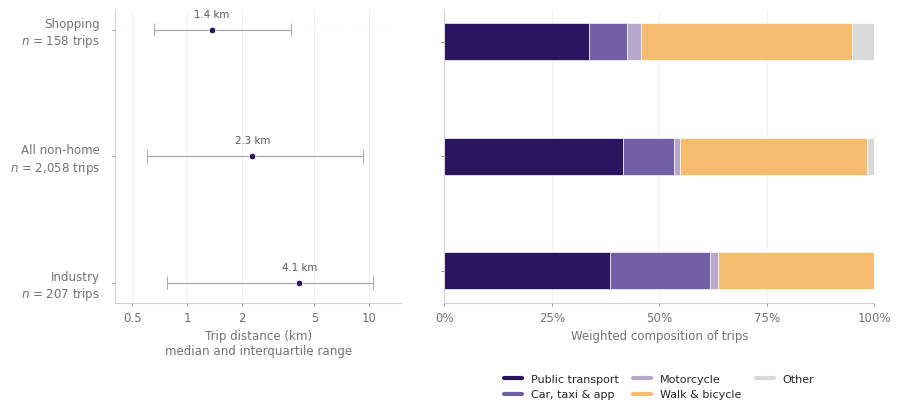

Saved: /Users/mixednutgiftpack/Documents/CASA/OD2017_2023/figs/c6_fig16_how_de_2023.png


In [19]:
FIGURE_PATH = (
    FIGURES
    / "c6_fig16_how_de_2023.png"
)

# Prepare D–E trips

for column in [
    "fe_via",
    "distancia",
    "modoprin",
    "motivo_d",
]:
    trips[column] = pd.to_numeric(
        trips[column],
        errors="coerce",
    )


de_trips = trips.loc[
    trips["class6"].eq("DE")
    & trips["motivo_d"].ne(8)
    & trips["fe_via"].gt(0)
].copy()


MODE_GROUP = {
    1: "Public transport",
    2: "Public transport",
    3: "Public transport",
    4: "Public transport",
    5: "Public transport",
    6: "Public transport",

    9: "Car, taxi & app",
    10: "Car, taxi & app",
    11: "Car, taxi & app",
    12: "Car, taxi & app",

    13: "Motorcycle",
    14: "Motorcycle",
    15: "Motorcycle",

    16: "Walk & bicycle",
    17: "Walk & bicycle",

    7: "Other",
    8: "Other",
    18: "Other",
}

MODES = [
    "Public transport",
    "Car, taxi & app",
    "Motorcycle",
    "Walk & bicycle",
    "Other",
]

MODE_COLOURS = {
    "Public transport": "#2B145F",
    "Car, taxi & app": "#735FA6",
    "Motorcycle": "#B6A7CD",
    "Walk & bicycle": "#F6BD70",
    "Other": "#D9D9D9",
}

de_trips["mode"] = (
    de_trips["modoprin"]
    .map(MODE_GROUP)
    .fillna("Other")
)


GROUPS = {
    "Industry": (
        de_trips.loc[
            de_trips["motivo_d"].eq(1)
        ]
    ),
    "All non-home": de_trips,
    "Shopping": (
        de_trips.loc[
            de_trips["motivo_d"].eq(5)
        ]
    ),
}


# Summary functions
def weighted_quantile(
    values,
    weights,
    quantiles,
):
    """Calculate survey-weighted quantiles."""
    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    quantiles = np.atleast_1d(
        quantiles
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if values.size == 0:
        return np.full(
            quantiles.size,
            np.nan,
        )

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]

    cumulative = (
        np.cumsum(weights)
        - 0.5 * weights
    ) / weights.sum()

    return np.interp(
        quantiles,
        cumulative,
        values,
    )
def distance_summary(data):
    """Return weighted q25, median and q75 in kilometres."""
    valid = data.dropna(
        subset=[
            "distancia",
            "fe_via",
        ]
    )

    return weighted_quantile(
        valid["distancia"] / 1000,
        valid["fe_via"],
        [0.25, 0.50, 0.75],
    )


def mode_composition(data):
    """Return survey-weighted mode shares."""
    weights = (
        data
        .groupby("mode")["fe_via"]
        .sum()
        .reindex(
            MODES,
            fill_value=0,
        )
    )

    return weights / weights.sum()


# Draw figure
INK = "#262329"
INK_LIGHT = "#77727A"
GRID = "#ECEAEC"
SPINE = "#D4D0D5"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(9.8, 3.8),
    gridspec_kw={
        "width_ratios": [0.9, 1.35],
        "wspace": 0.12,
    },
    facecolor="white",
)

y_positions = (
    np.arange(len(GROUPS)) * 0.68
)


# Left panel: trip distance
distance_axis = axes[0]
row_labels = []

for y, (
    label,
    data,
) in zip(
    y_positions,
    GROUPS.items(),
):
    q25, median, q75 = distance_summary(
        data
    )

    if np.isfinite(
        [q25, median, q75]
    ).all():
        q25, median, q75 = np.maximum(
            [q25, median, q75],
            0.25,
        )

        distance_axis.hlines(
            y,
            q25,
            q75,
            color="#AAA4B0",
            linewidth=0.85,
            zorder=2,
        )

        distance_axis.vlines(
            [q25, q75],
            y - 0.035,
            y + 0.035,
            color="#AAA4B0",
            linewidth=0.7,
            zorder=2,
        )

        distance_axis.scatter(
            median,
            y,
            s=23,
            color="#2B145F",
            edgecolor="white",
            linewidth=0.65,
            zorder=3,
        )

        distance_axis.annotate(
            f"{median:.1f} km",
            (median, y),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=7.4,
            color="#5C5660",
        )

    row_labels.append(
        f"{label}\n"
        f"$n$ = {len(data):,} trips"
    )


distance_axis.set(
    xscale="log",
    xlim=(0.4, 15),
    xticks=[0.5, 1, 2, 5, 10],
    xticklabels=["0.5", "1", "2", "5", "10"],
    yticks=y_positions,
    yticklabels=row_labels,
    xlabel=(
        "Trip distance (km)\n"
        "median and interquartile range"
    ),
)

distance_axis.minorticks_off()

distance_axis.tick_params(
    axis="y",
    length=0,
    pad=8,
)

distance_axis.grid(
    axis="x",
    color=GRID,
    linewidth=0.5,
)

distance_axis.grid(
    axis="y",
    color="#F1EFF2",
    linewidth=0.45,
    linestyle=(0, (1.5, 3)),
)

# Right panel: mode composition
mode_axis = axes[1]

for y, data in zip(
    y_positions,
    GROUPS.values(),
):
    shares = mode_composition(data)
    left = 0

    for mode in MODES:
        mode_axis.barh(
            y,
            shares[mode],
            left=left,
            height=0.22,
            color=MODE_COLOURS[mode],
            edgecolor="white",
            linewidth=0.45,
        )

        left += shares[mode]


mode_axis.set(
    xlim=(0, 1),
    xticks=[0, 0.25, 0.5, 0.75, 1],
    xticklabels=[
        "0%",
        "25%",
        "50%",
        "75%",
        "100%",
    ],
    yticks=y_positions,
    yticklabels=[],
    xlabel="Weighted composition of trips",
)

mode_axis.invert_yaxis()

mode_axis.grid(
    axis="x",
    color=GRID,
    linewidth=0.5,
)


# Shared style and legend
for axis in axes:
    axis.spines[
        ["top", "right"]
    ].set_visible(False)

    axis.spines[
        ["left", "bottom"]
    ].set_color(SPINE)

    axis.tick_params(
        colors=INK_LIGHT,
        labelsize=8.5,
        width=0.55,
        length=2.5,
    )

    axis.xaxis.label.set(
        color=INK_LIGHT,
        fontsize=8.5,
    )

    axis.set_axisbelow(True)


legend_handles = [
    Line2D(
        [],
        [],
        color=MODE_COLOURS[mode],
        linewidth=3,
        solid_capstyle="round",
        label=mode,
    )
    for mode in MODES
]

mode_axis.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.21),
    ncol=3,
    frameon=False,
    fontsize=8,
    labelcolor=INK,
    columnspacing=1.3,
    handlelength=1.6,
)



fig.tight_layout(
    rect=[0, 0.08, 1, 0.94]
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved: {FIGURE_PATH}")